In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import csv
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_excel("auto_mpg_.xlsx")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,15.36,6,245.84,228.30,3454.88,10.76,71,2,BMW Sport 452
1,16.74,8,345.15,127.83,3501.31,22.63,73,3,Kia Z 350
2,14.08,5,184.45,55.82,3922.71,NaN,82,1,Toyota DX 987
3,19.73,8,245.84,104.44,3560.45,21.44,73,3,Volkswagen Elite 644
4,22.78,8,153.37,NaN,2692.03,10.02,73,1,Toyota LX 411


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical summary:")
display(df.describe(include="all"))

Shape of dataset: (50000, 9)

Columns:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

First 5 rows:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,15.36,6,245.84,228.30,3454.88,10.76,71,2,BMW Sport 452
1,16.74,8,345.15,127.83,3501.31,22.63,73,3,Kia Z 350
2,14.08,5,184.45,55.82,3922.71,NaN,82,1,Toyota DX 987
3,19.73,8,245.84,104.44,3560.45,21.44,73,3,Volkswagen Elite 644
4,22.78,8,153.37,NaN,2692.03,10.02,73,1,Toyota LX 411



Statistical summary:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
count,50000.000000,50000.000000,50000.000000,47500.000000,47500.000000,47500.000000,50000.000000,50000.000000,50000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38385
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chevrolet Elite 645
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,19.415249,5.210620,260.117700,139.887012,3260.167928,16.001843,76.009340,2.000880,NaN
std,10.423535,1.724575,109.640135,51.971821,1008.961746,4.628093,3.743166,0.818347,NaN
min,-5.850000,3.000000,70.000000,50.000000,1500.020000,8.000000,70.000000,1.000000,NaN
25%,10.640000,4.000000,165.052500,94.587500,2390.592500,11.960000,73.000000,1.000000,NaN
50%,19.380000,5.000000,260.615000,140.040000,3261.295000,15.985000,76.000000,2.000000,NaN
75%,28.170000,6.000000,355.820000,184.752500,4131.045000,20.000000,79.000000,3.000000,NaN


In [4]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)

print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')


In [5]:
print("Missing values before cleaning:")
df.isnull().sum()

Missing values before cleaning:


mpg                0
cylinders          0
displacement       0
horsepower      2500
weight          2500
acceleration    2500
model_year         0
origin             0
car_name           0
dtype: int64

In [6]:
# Remove duplicates if any
df = df.drop_duplicates()

# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,15.36,6,245.84,228.30,3454.88,10.760,71,2,BMW Sport 452
1,16.74,8,345.15,127.83,3501.31,22.630,73,3,Kia Z 350
2,14.08,5,184.45,55.82,3922.71,15.985,82,1,Toyota DX 987
3,19.73,8,245.84,104.44,3560.45,21.440,73,3,Volkswagen Elite 644
4,22.78,8,153.37,140.04,2692.03,10.020,73,1,Toyota LX 411


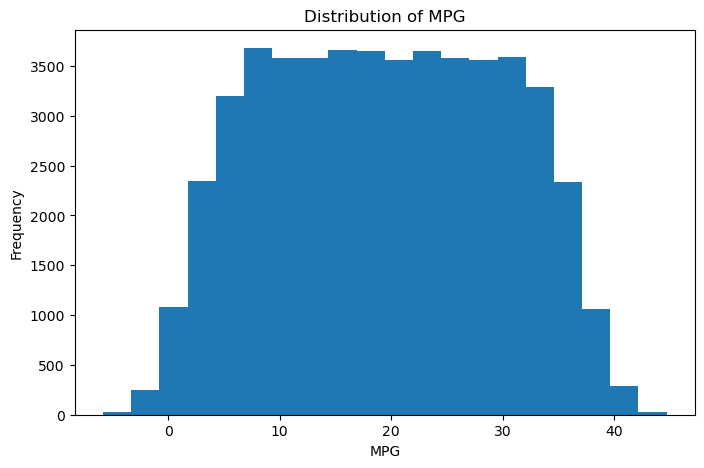

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"], bins=20)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()

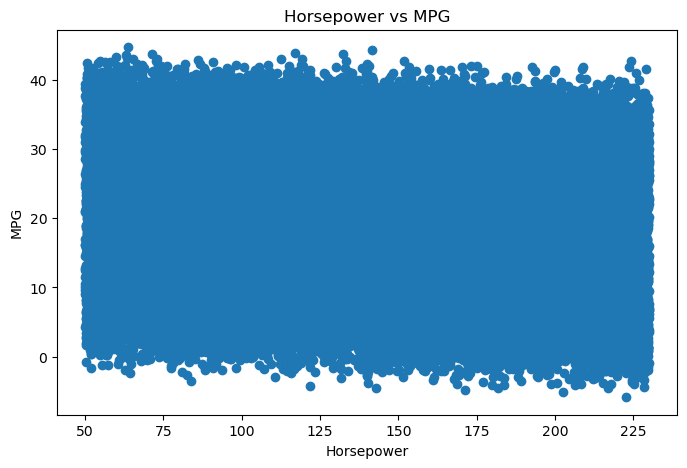

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["horsepower"], df["mpg"])
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

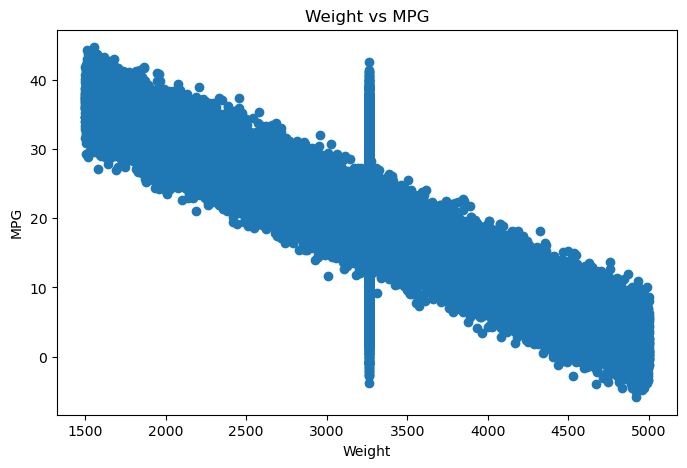

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["weight"], df["mpg"])
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

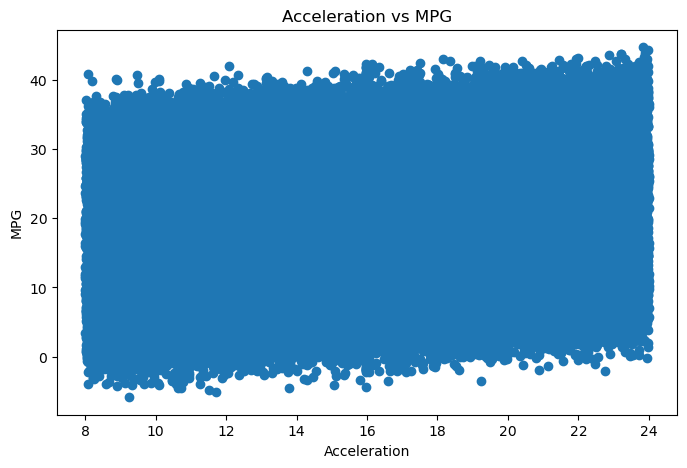

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["acceleration"], df["mpg"])
plt.title("Acceleration vs MPG")
plt.xlabel("Acceleration")
plt.ylabel("MPG")
plt.show()

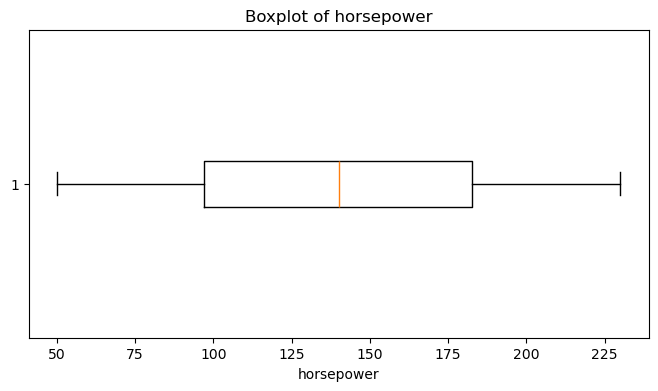

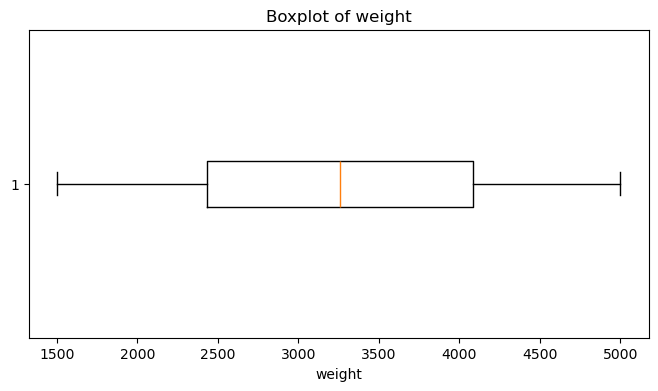

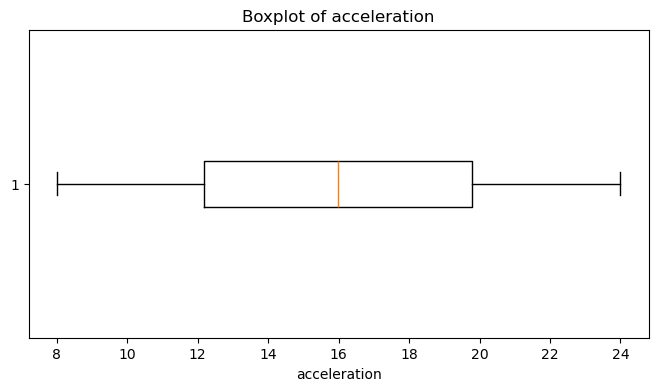

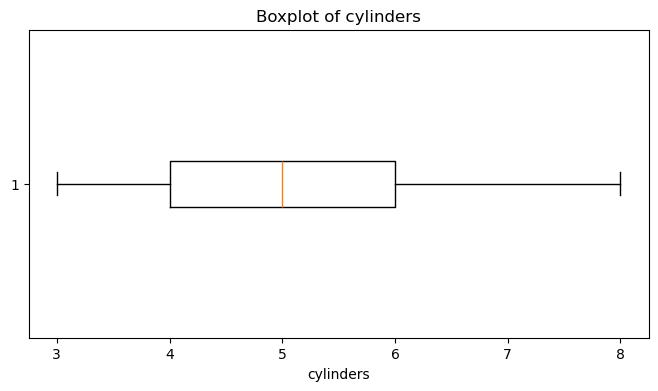

In [12]:
for col in ["horsepower", "weight", "acceleration", "cylinders"]:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [13]:
corr = df.select_dtypes(include=[np.number]).corr()
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,0.008134,0.000062,-0.093791,-0.943167,0.133131,0.001378,-0.002848
cylinders,0.008134,1.000000,-0.001258,0.000063,-0.007504,0.007213,-0.001764,-0.003788
displacement,0.000062,-0.001258,1.000000,0.002847,-0.002347,-0.005566,-0.009225,-0.005523
horsepower,-0.093791,0.000063,0.002847,1.000000,-0.001239,-0.000017,-0.006228,-0.001018
weight,-0.943167,-0.007504,-0.002347,-0.001239,1.000000,-0.004420,-0.002608,0.004526
acceleration,0.133131,0.007213,-0.005566,-0.000017,-0.004420,1.000000,-0.002220,0.008686
model_year,0.001378,-0.001764,-0.009225,-0.006228,-0.002608,-0.002220,1.000000,0.003112
origin,-0.002848,-0.003788,-0.005523,-0.001018,0.004526,0.008686,0.003112,1.000000


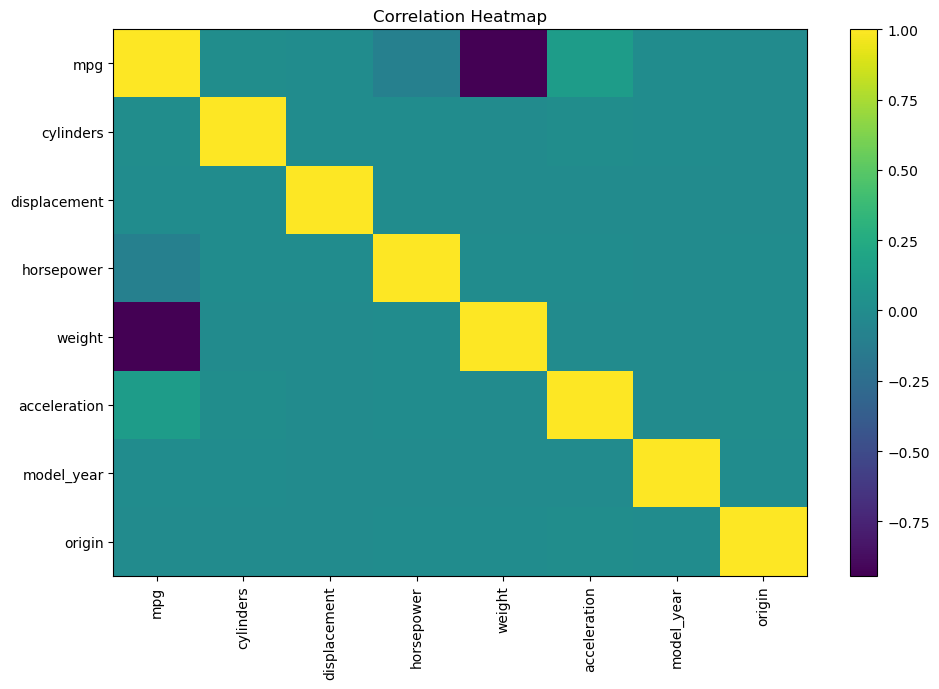

In [14]:
plt.figure(figsize=(10, 7))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
selected_features = ["cylinders", "horsepower", "weight", "acceleration"]
target = "mpg"

X = df[selected_features]
y = df[target]

print("Selected features:")
print(selected_features)

print("\nFeature correlation with MPG:")
print(df[selected_features + [target]].corr()["mpg"].sort_values(ascending=False))

Selected features:
['cylinders', 'horsepower', 'weight', 'acceleration']

Feature correlation with MPG:
mpg             1.000000
acceleration    0.133131
cylinders       0.008134
horsepower     -0.093791
weight         -0.943167
Name: mpg, dtype: float64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40000, 4)
X_test shape: (10000, 4)


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    return {
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Estimator": model
    }

In [19]:
lr = LinearRegression()

lr_result = evaluate_model(
    "Linear Regression",
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

lr_result

{'Model': 'Linear Regression',
 'R2': 0.9122883364476796,
 'MAE': 2.0157929762812667,
 'RMSE': 3.062510120661347,
 'Estimator': LinearRegression()}

In [20]:
dt_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        "max_depth": [3, 5, 7, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_result = evaluate_model(
    "Decision Tree",
    dt_search,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

dt_result

{'Model': 'Decision Tree',
 'R2': 0.9042415831225832,
 'MAE': 2.175977313536172,
 'RMSE': 3.199906859216183,
 'Estimator': GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
              param_grid={'max_depth': [3, 5, 7, None],
                          'min_samples_leaf': [1, 2, 4],
                          'min_samples_split': [2, 5, 10]},
              scoring='r2')}

In [21]:
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_result = evaluate_model(
    "Random Forest",
    rf_search,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

rf_result

{'Model': 'Random Forest',
 'R2': 0.9108674931119869,
 'MAE': 2.044985553565275,
 'RMSE': 3.087215309947939,
 'Estimator': GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
              param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                          'min_samples_split': [2, 5],
                          'n_estimators': [100, 200]},
              scoring='r2')}

In [22]:
results_df = pd.DataFrame([
    {k: v for k, v in lr_result.items() if k != "Estimator"},
    {k: v for k, v in dt_result.items() if k != "Estimator"},
    {k: v for k, v in rf_result.items() if k != "Estimator"},
])

results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Linear Regression,0.912288,2.015793,3.062510
1,Random Forest,0.910867,2.044986,3.087215
2,Decision Tree,0.904242,2.175977,3.199907


In [23]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model is:", best_model_name)

Best model is: Linear Regression


In [24]:
if best_model_name == "Linear Regression":
    final_model = LinearRegression()

elif best_model_name == "Decision Tree":
    best_params = dt_search.best_params_
    final_model = DecisionTreeRegressor(
        random_state=42,
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"]
    )

else:
    best_params = rf_search.best_params_
    final_model = RandomForestRegressor(
        random_state=42,
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"]
    )

final_model.fit(X_train_scaled, y_train)
final_preds = final_model.predict(X_test_scaled)

final_r2 = r2_score(y_test, final_preds)
final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = mean_squared_error(y_test, final_preds) ** 0.5

print("Final R2:", final_r2)
print("Final MAE:", final_mae)
print("Final RMSE:", final_rmse)

Final R2: 0.9122883364476796
Final MAE: 2.0157929762812667
Final RMSE: 3.062510120661347


In [25]:
with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("accuracy.pkl", "wb") as f:
    pickle.dump(float(final_r2), f)

print("Saved successfully:")
print("model.pkl")
print("scaler.pkl")
print("accuracy.pkl")

Saved successfully:
model.pkl
scaler.pkl
accuracy.pkl


In [26]:
LOG_FILE = "prediction_logs.csv"

def log_prediction(cylinders, horsepower, weight, acceleration, prediction):
    file_exists = os.path.exists(LOG_FILE)

    with open(LOG_FILE, "a", newline="") as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow([
                "timestamp",
                "cylinders",
                "horsepower",
                "weight",
                "acceleration",
                "prediction"
            ])

        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            cylinders,
            horsepower,
            weight,
            acceleration,
            prediction
        ])

# Example monitoring log
log_prediction(4, 120, 2800, 15, 27.5)

print("Monitoring file created/updated:", LOG_FILE)

Monitoring file created/updated: prediction_logs.csv


In [27]:
logs = pd.read_csv("prediction_logs.csv")
logs.tail()

,timestamp,cylinders,horsepower,weight,acceleration,prediction
0,2026-04-02 10:22:14,4,120,2800,15,27.5


In [28]:
print("Project completed successfully.")
print("Requirements fulfilled:")
print("- Data Collection and Understanding")
print("- Data Cleaning and Preprocessing")
print("- Exploratory Data Analysis")
print("- Feature Engineering and Selection")
print("- Model Training, Evaluation, and Tuning")
print("- Ensemble Methods")
print("- Monitoring")
print("- Frontend with Home, Prediction, and About Page")

Project completed successfully.
Requirements fulfilled:
- Data Collection and Understanding
- Data Cleaning and Preprocessing
- Exploratory Data Analysis
- Feature Engineering and Selection
- Model Training, Evaluation, and Tuning
- Ensemble Methods
- Monitoring
- Frontend with Home, Prediction, and About Page
